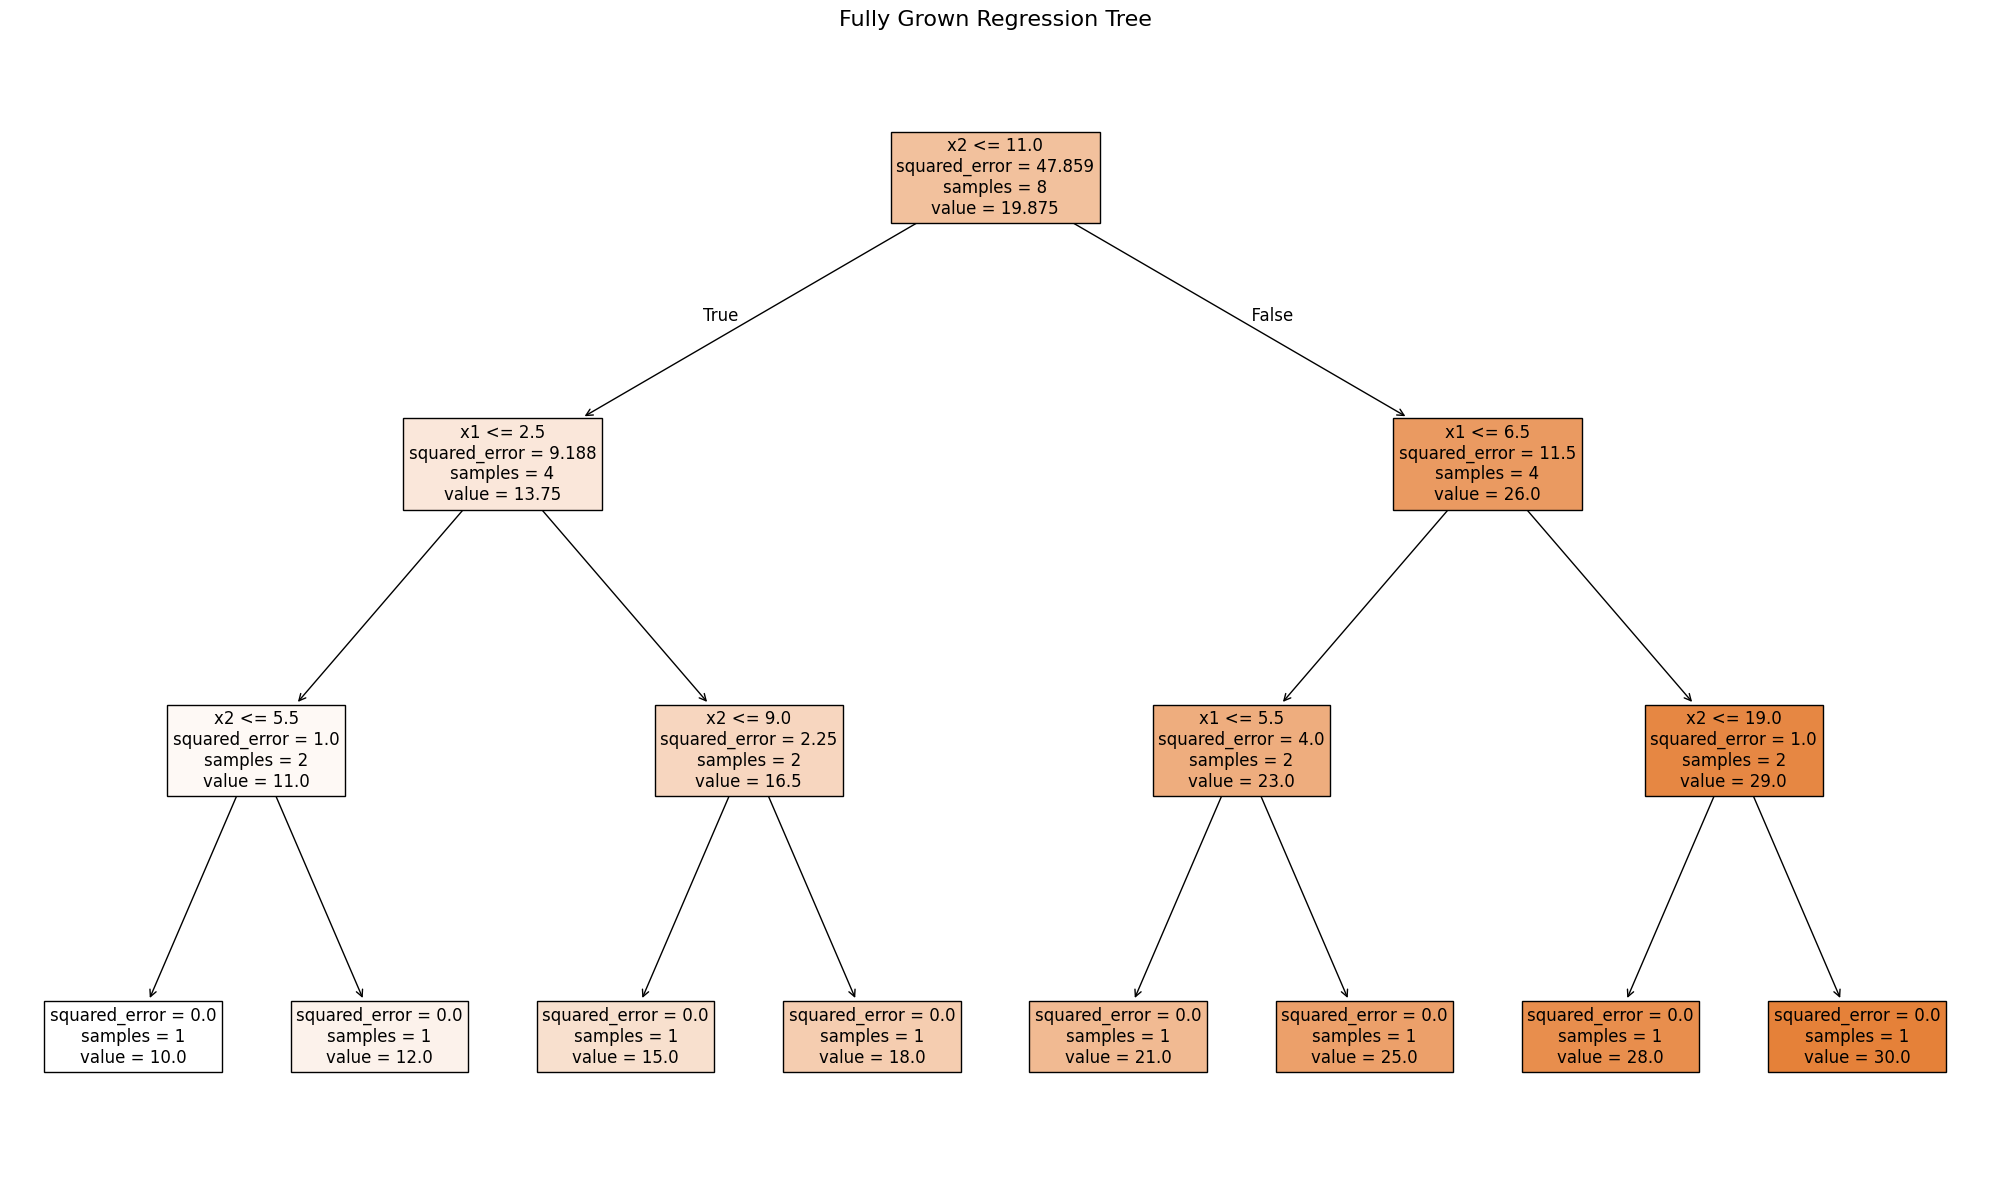

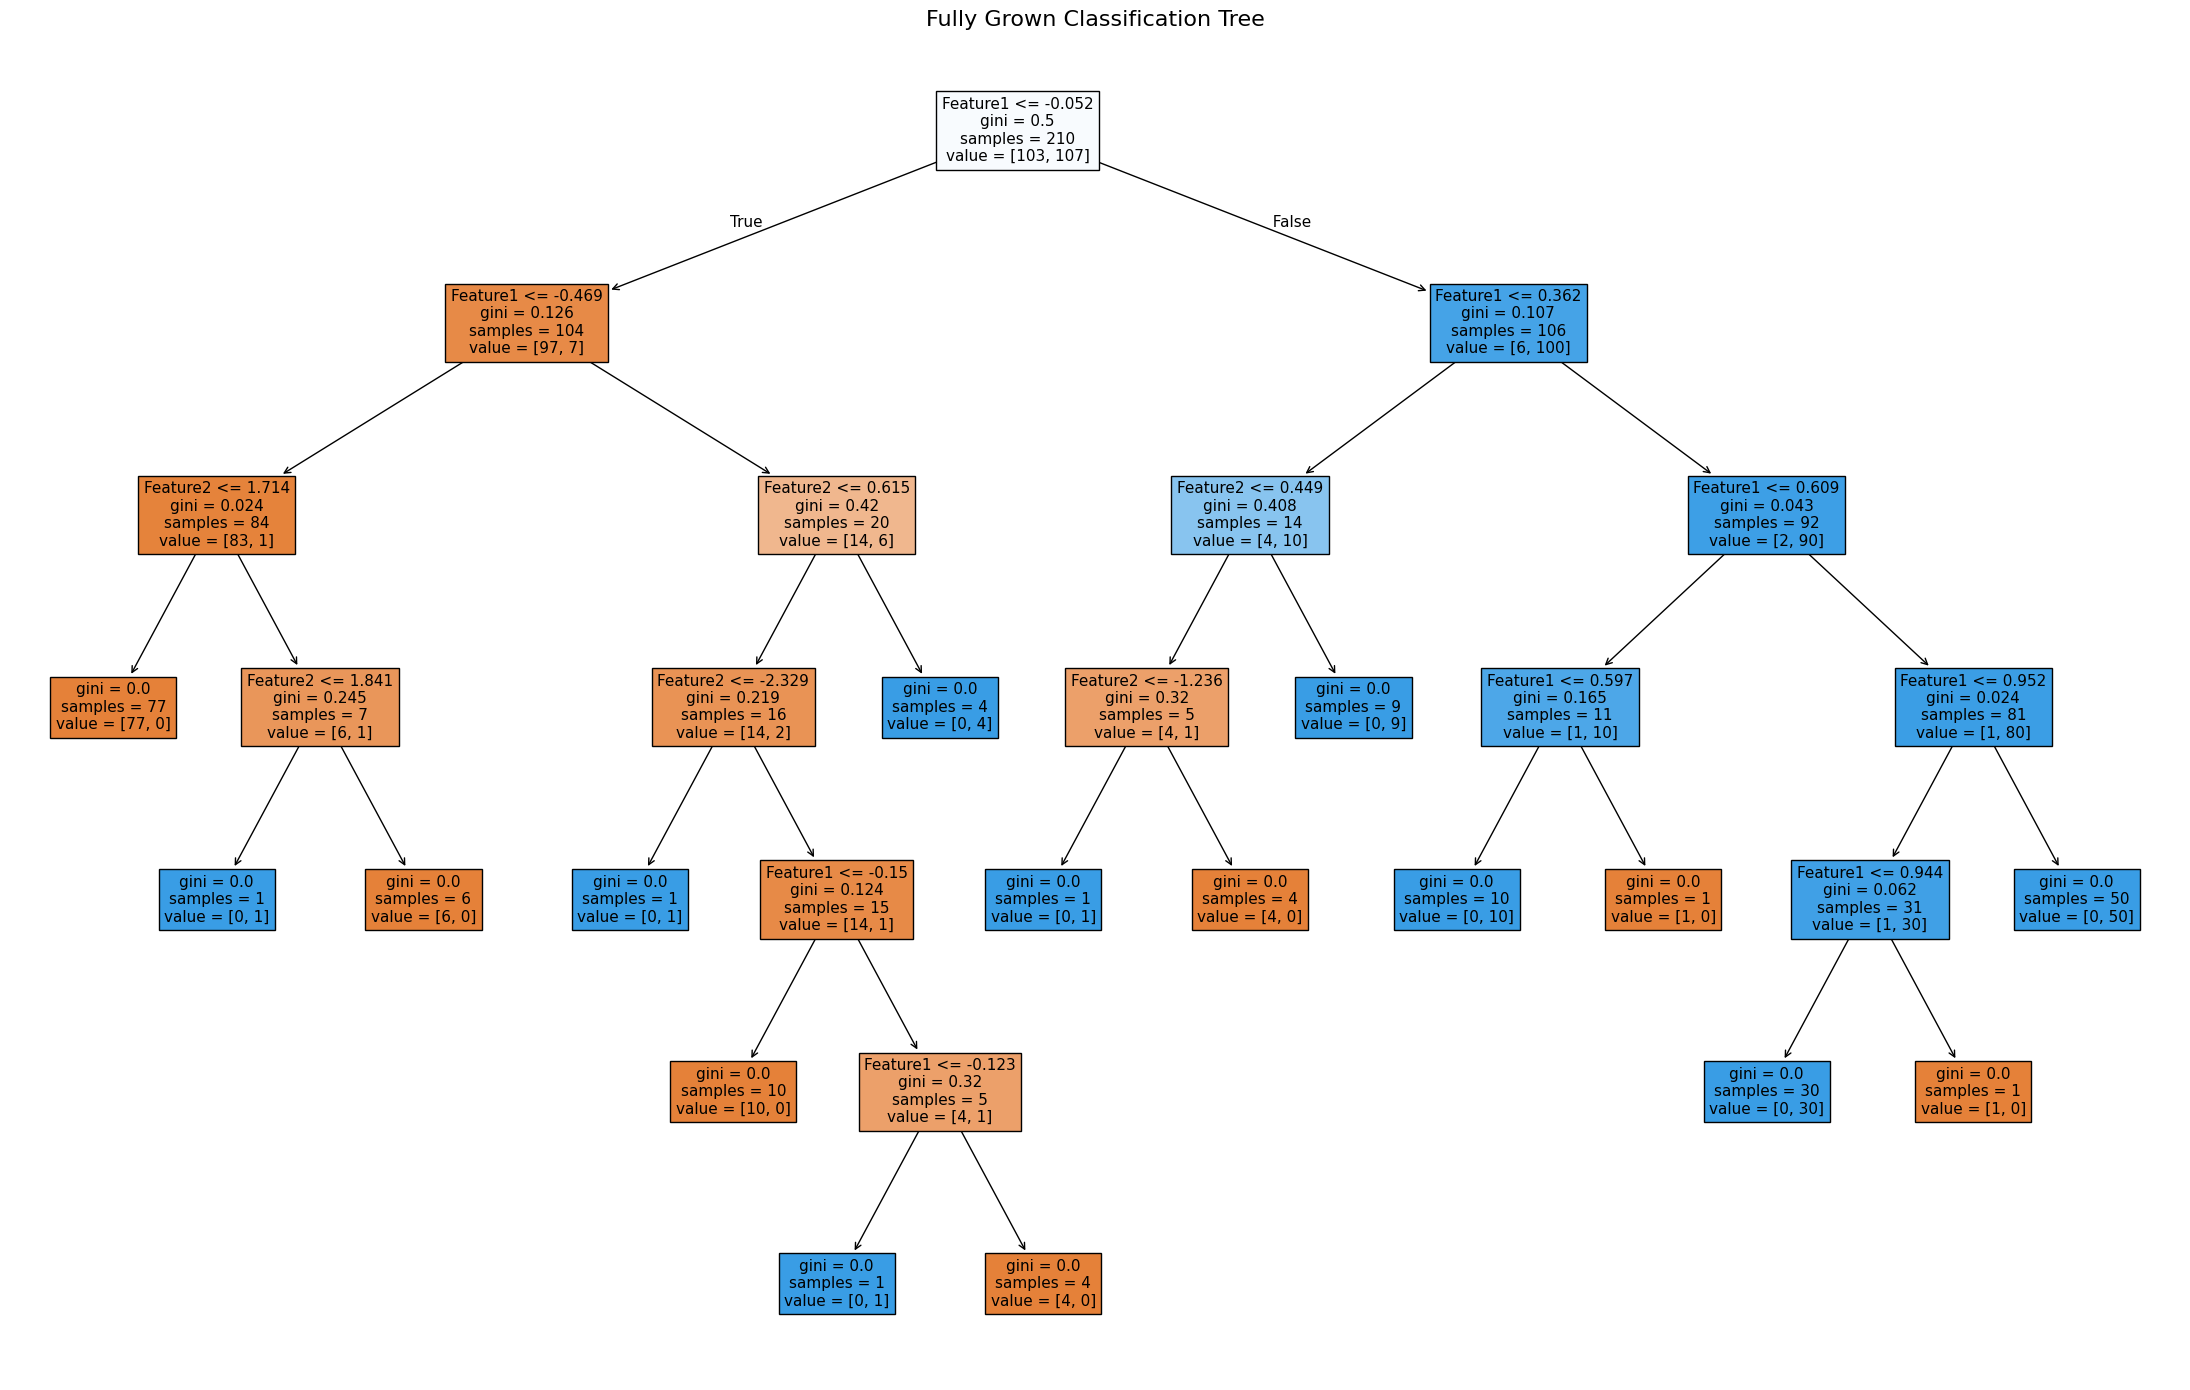

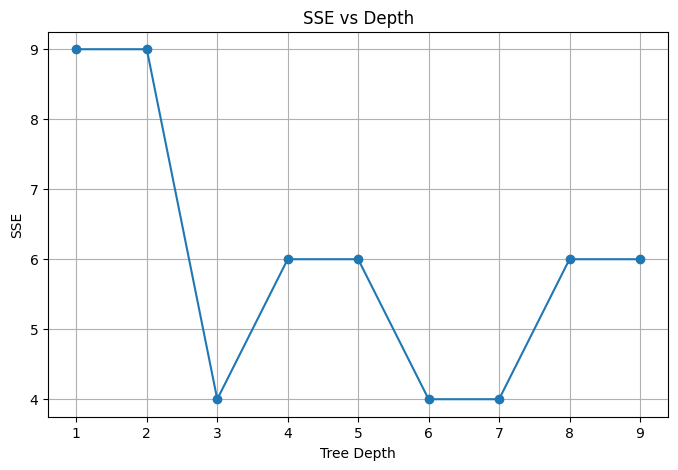

Optimal Depth: 1


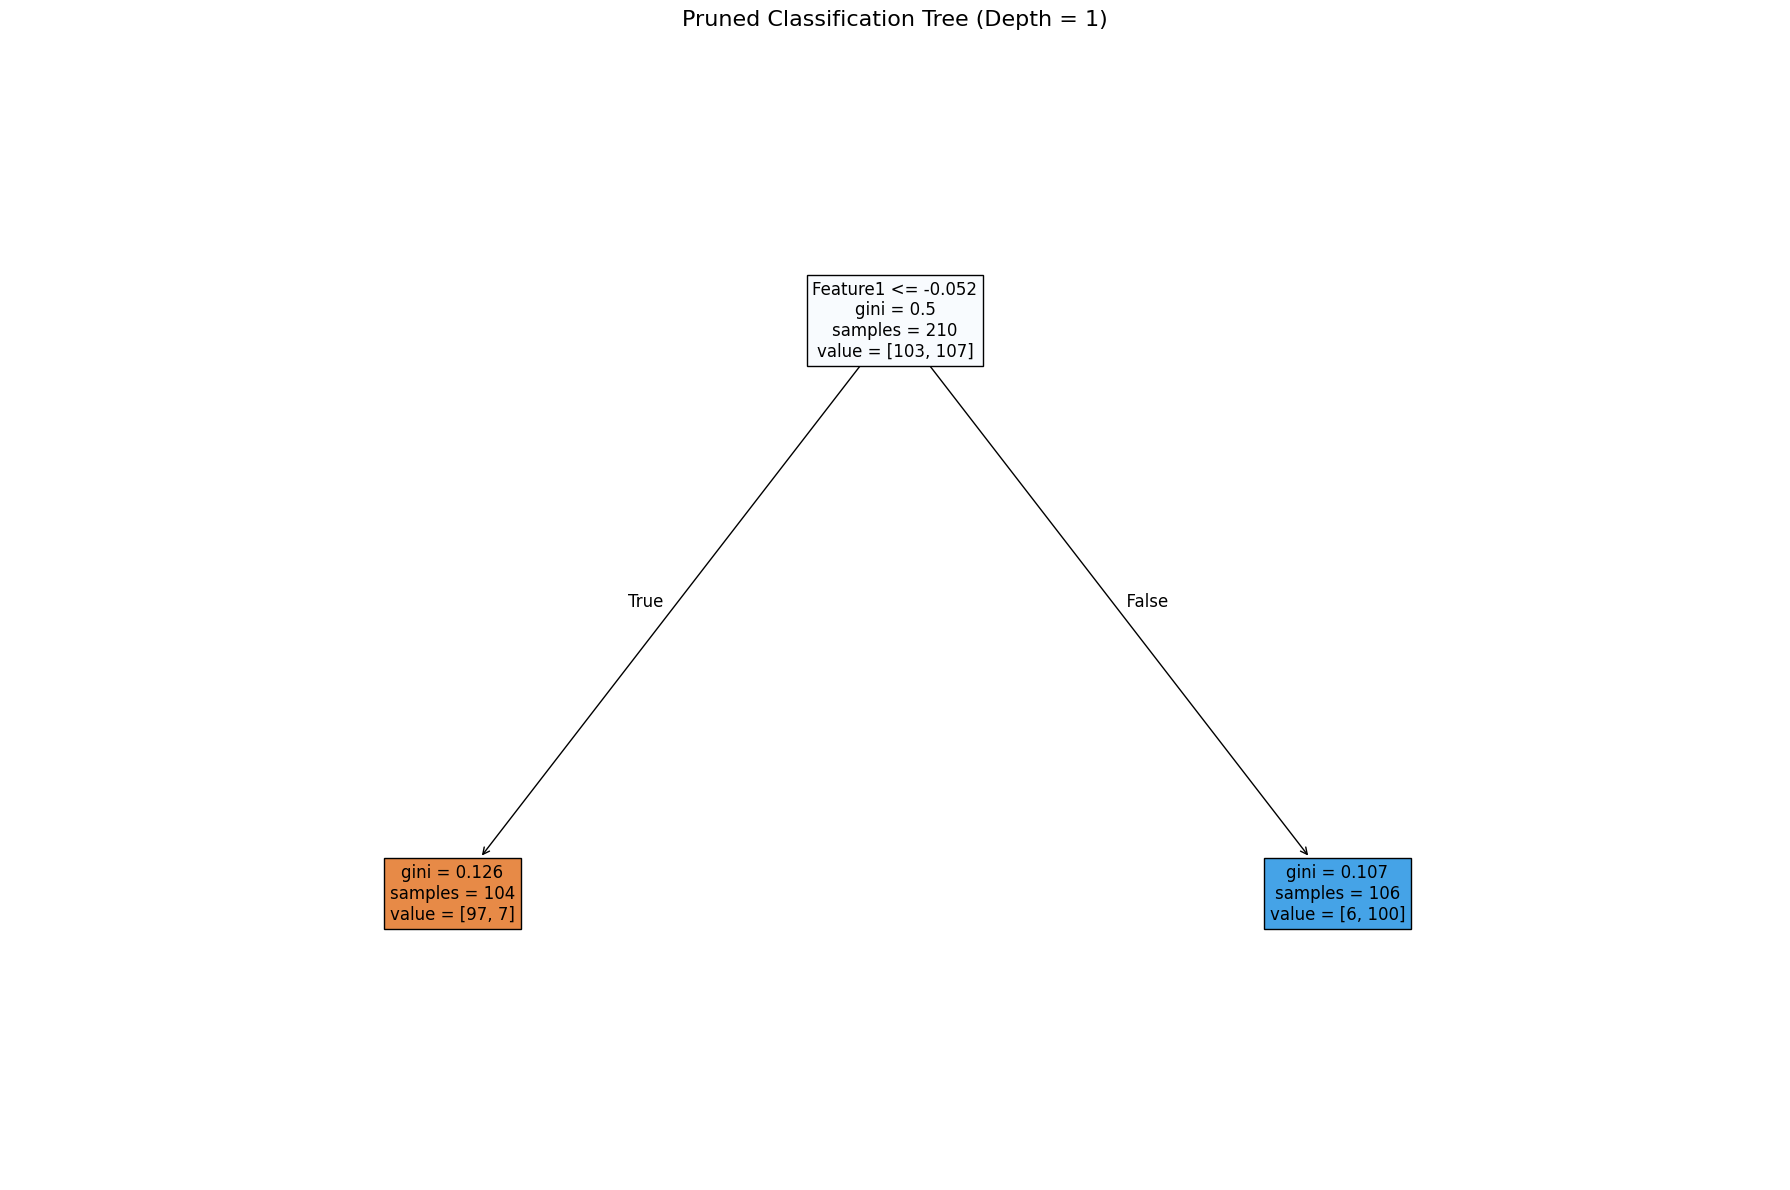

In [9]:
# =========================================
# IMPORT LIBRARIES
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# =========================================
# Q7: REGRESSION TREE
# =========================================

data = {
    'x1': [1,2,3,4,5,6,7,8],
    'x2': [5,6,8,10,12,15,18,20],
    'y':  [10,12,15,18,21,25,28,30]
}

df = pd.DataFrame(data)

X_reg = df[['x1', 'x2']]
y_reg = df['y']

reg_model = DecisionTreeRegressor()
reg_model.fit(X_reg, y_reg)

# ✅ Bigger canvas + decent font
plt.figure(figsize=(20,12))
plot_tree(reg_model,
          feature_names=['x1','x2'],
          filled=True,
          fontsize=12)
plt.title("Fully Grown Regression Tree", fontsize=16)
plt.tight_layout()
plt.show()


# =========================================
# Q8: CLASSIFICATION TREE
# =========================================

train = pd.read_csv("A4_train.csv")
test = pd.read_csv("A4_test.csv")

X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

# -----------------------------------------
# (a) FULL TREE
# -----------------------------------------
clf = DecisionTreeClassifier(criterion='gini')
clf.fit(X_train, y_train)

plt.figure(figsize=(22,14))  # VERY IMPORTANT
plot_tree(clf,
          feature_names=X_train.columns,
          filled=True,
          fontsize=11)
plt.title("Fully Grown Classification Tree", fontsize=16)
plt.tight_layout()
plt.show()


# -----------------------------------------
# (b) SSE vs DEPTH
# -----------------------------------------
depths = range(1, 10)
sse_values = []

for d in depths:
    temp_model = DecisionTreeClassifier(max_depth=d)
    temp_model.fit(X_train, y_train)

    y_pred = temp_model.predict(X_test)
    sse = np.sum((y_test - y_pred)**2)
    sse_values.append(sse)

plt.figure(figsize=(8,5))
plt.plot(depths, sse_values, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("SSE")
plt.title("SSE vs Depth")
plt.grid()
plt.show()


# -----------------------------------------
# (c) OPTIMAL DEPTH
# -----------------------------------------
diff = np.diff(sse_values)
best_index = np.argmin(np.abs(diff))
optimal_depth = depths[best_index]

print("Optimal Depth:", optimal_depth)


# -----------------------------------------
# (d) PRUNED TREE (BEST LOOK)
# -----------------------------------------
pruned_model = DecisionTreeClassifier(max_depth=optimal_depth)
pruned_model.fit(X_train, y_train)

plt.figure(figsize=(18,12))  # balanced size
plot_tree(pruned_model,
          feature_names=X_train.columns,
          filled=True,
          fontsize=12)
plt.title(f"Pruned Classification Tree (Depth = {optimal_depth})", fontsize=16)
plt.tight_layout()
plt.show()